## DSAN 5650 Workshop 5: PyMC's `idata` (Inference Data) Structure

## 1 "Customizable" Regression with PyMC

This is copied from Part 4 of Workshop 4, so that we can pick up where we left off last week, with our model of the impact of slave exports on present-day GDP, and the posterior distribution information stored as an `idata` object!

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm
import arviz as az
import xarray as xr
import preliz as pz

In [44]:
nunn_data_url = "https://github.com/jpowerj/dsan-content/raw/refs/heads/main/2026-sum-dsan5650/workshop01/slave_trade_QJE.dta"
country_df = pd.read_stata(nunn_data_url)
country_df.head()

,isocode,country,ln_maddison_pcgdp2000,ln_export_area,ln_export_pop,colony0,colony1,colony2,colony3,colony4,...,ln_avg_oil_pop,ln_avg_all_diamonds_pop,ln_pop_dens_1400,atlantic_distance_minimum,indian_distance_minimum,saharan_distance_minimum,red_sea_distance_minimum,ethnic_fractionalization,state_dev,land_area
0,AGO,Angola,6.670766,7.967494,14.399250,0.0,0.0,0.0,1.0,0.0,...,0.643126,-1.701396,-0.024917,5.668760,6.980571,4.925892,3.872354,0.7867,0.635,1.2500
1,BDI,Burundi,6.354370,1.140843,4.451658,0.0,0.0,0.0,0.0,1.0,...,-9.210340,-6.907755,3.036856,10.626214,2.570375,3.718742,2.215324,0.2951,0.995,0.0278
2,BEN,Benin,7.187657,8.304137,13.308970,0.0,0.0,1.0,0.0,0.0,...,-3.531555,-6.907755,1.214196,5.120652,9.233961,2.834785,3.901736,0.7872,0.695,0.1130
3,BFA,Burkina Faso,6.748760,6.413822,11.724286,0.0,0.0,1.0,0.0,0.0,...,-9.210340,-6.907755,0.908565,4.774938,9.299419,2.763519,4.239375,0.7377,0.338,0.2740
4,BWA,Botswana,8.377471,-2.302585,3.912023,0.0,1.0,0.0,0.0,0.0,...,-9.210340,2.186849,-2.075029,5.686335,5.764575,5.856533,4.299600,0.4102,0.893,0.6000


### 1.1 Indexing in Pandas

By default, Pandas just assigns a **numeric index** which "labels" each row with **coordinate values starting from 0 to (in this case) 51**, so that the first country (Angola) has index 0, the second country (Burundi) has index 1, and so on:

In [66]:
country_df

,isocode,country,ln_maddison_pcgdp2000,ln_export_area,ln_export_pop,colony0,colony1,colony2,colony3,colony4,...,ln_avg_oil_pop,ln_avg_all_diamonds_pop,ln_pop_dens_1400,atlantic_distance_minimum,indian_distance_minimum,saharan_distance_minimum,red_sea_distance_minimum,ethnic_fractionalization,state_dev,land_area
0,AGO,Angola,6.670766,7.967494,14.399250,0.0,0.0,0.0,1.0,0.0,...,0.643126,-1.701396,-0.024917,5.668760,6.980571,4.925892,3.872354,0.7867,0.635,1.250000
1,BDI,Burundi,6.354370,1.140843,4.451658,0.0,0.0,0.0,0.0,1.0,...,-9.210340,-6.907755,3.036856,10.626214,2.570375,3.718742,2.215324,0.2951,0.995,0.027800
2,BEN,Benin,7.187657,8.304137,13.308970,0.0,0.0,1.0,0.0,0.0,...,-3.531555,-6.907755,1.214196,5.120652,9.233961,2.834785,3.901736,0.7872,0.695,0.113000
3,BFA,Burkina Faso,6.748760,6.413822,11.724286,0.0,0.0,1.0,0.0,0.0,...,-9.210340,-6.907755,0.908565,4.774938,9.299419,2.763519,4.239375,0.7377,0.338,0.274000
4,BWA,Botswana,8.377471,-2.302585,3.912023,0.0,1.0,0.0,0.0,0.0,...,-9.210340,2.186849,-2.075029,5.686335,5.764575,5.856533,4.299600,0.4102,0.893,0.600000
5,CAF,Central African Republic,6.472346,1.171314,8.052058,0.0,0.0,1.0,0.0,0.0,...,-9.210340,-1.849576,-0.473905,5.642056,8.772295,2.840084,2.293167,0.8295,0.144,0.623000
6,CIV,Ivory Coast,7.189922,5.096793,10.843699,0.0,0.0,1.0,0.0,0.0,...,-3.270892,-4.228216,0.472123,4.185696,9.457085,3.353074,4.793966,0.8204,0.082,0.322000
7,CMR,Cameroon,7.016610,4.944928,10.331063,0.0,0.0,1.0,0.0,0.0,...,-0.871162,-6.907755,1.020704,5.642056,8.772295,3.002548,3.051031,0.8635,0.316,0.475000
8,COG,Congo,7.702556,5.623267,12.391068,0.0,0.0,1.0,0.0,0.0,...,1.000878,-6.907755,-0.360961,5.527229,7.923528,3.697363,3.227007,0.8747,0.536,0.342000
9,COM,Comoros,6.364751,-2.302585,3.912023,0.0,0.0,1.0,0.0,0.0,...,-9.210340,-6.907755,-2.302585,10.130652,1.754229,4.845693,2.609506,0.0000,1.000,0.002170


However, you don't have to use this default index if you have specific information that is more helpful for you to **identify** each row! In PyMC, for example, you'll obtain a posterior distribution of GDP values for each country, so that instead of having to say *"Hm, which country has index 30..."*, you can just directly make the country's **name** the index:

In [67]:
country_df.set_index('country')

,isocode,ln_maddison_pcgdp2000,ln_export_area,ln_export_pop,colony0,colony1,colony2,colony3,colony4,colony5,...,ln_avg_oil_pop,ln_avg_all_diamonds_pop,ln_pop_dens_1400,atlantic_distance_minimum,indian_distance_minimum,saharan_distance_minimum,red_sea_distance_minimum,ethnic_fractionalization,state_dev,land_area
country,,,,,,,,,,,,,,,,,,,,,
Angola,AGO,6.670766,7.967494,14.399250,0.0,0.0,0.0,1.0,0.0,0.0,...,0.643126,-1.701396,-0.024917,5.668760,6.980571,4.925892,3.872354,0.7867,0.635,1.250000
Burundi,BDI,6.354370,1.140843,4.451658,0.0,0.0,0.0,0.0,1.0,0.0,...,-9.210340,-6.907755,3.036856,10.626214,2.570375,3.718742,2.215324,0.2951,0.995,0.027800
Benin,BEN,7.187657,8.304137,13.308970,0.0,0.0,1.0,0.0,0.0,0.0,...,-3.531555,-6.907755,1.214196,5.120652,9.233961,2.834785,3.901736,0.7872,0.695,0.113000
Burkina Faso,BFA,6.748760,6.413822,11.724286,0.0,0.0,1.0,0.0,0.0,0.0,...,-9.210340,-6.907755,0.908565,4.774938,9.299419,2.763519,4.239375,0.7377,0.338,0.274000
Botswana,BWA,8.377471,-2.302585,3.912023,0.0,1.0,0.0,0.0,0.0,0.0,...,-9.210340,2.186849,-2.075029,5.686335,5.764575,5.856533,4.299600,0.4102,0.893,0.600000
Central African Republic,CAF,6.472346,1.171314,8.052058,0.0,0.0,1.0,0.0,0.0,0.0,...,-9.210340,-1.849576,-0.473905,5.642056,8.772295,2.840084,2.293167,0.8295,0.144,0.623000
Ivory Coast,CIV,7.189922,5.096793,10.843699,0.0,0.0,1.0,0.0,0.0,0.0,...,-3.270892,-4.228216,0.472123,4.185696,9.457085,3.353074,4.793966,0.8204,0.082,0.322000
Cameroon,CMR,7.016610,4.944928,10.331063,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.871162,-6.907755,1.020704,5.642056,8.772295,3.002548,3.051031,0.8635,0.316,0.475000
Congo,COG,7.702556,5.623267,12.391068,0.0,0.0,1.0,0.0,0.0,0.0,...,1.000878,-6.907755,-0.360961,5.527229,7.923528,3.697363,3.227007,0.8747,0.536,0.342000


When we move to PyMC, the core data structure used is not a NumPy `np.array` nor a Pandas `DataFrame`, but an [xarray `DataArray`](https://docs.xarray.dev/en/stable/user-guide/data-structures.html#dataarray). And so, to similarly tell xarray that you'd like to index the rows by a dimension, `"country"` (whose values are the country **names**), rather than just a number from 0 to 51, you just need to construct a Python dictionary (`dict`) object telling PyMC the **name** of the dimension and the **possible values** that coordinates can take on within that dimension. In other words, by constructing the dictionary in the following code cell, we're telling PyMC that:

* Data observations are taken across a dimension called **`'country'`**, and that
* This `country` dimension can take on 52 possible values, which should be arranged to match the `country` column in `country_df` from above: the first observation's "coordinate value" on the `country` dimension is `"Angola"`, the second observation's "coordinate value" on this dimension is `"Burundi"`, and so on.

In [68]:
import pymc as pm

gdp_coords = {
  'country': country_df['country'].values,
}
print(gdp_coords)

{'country': <StringArray>
[                      'Angola',                      'Burundi',
                        'Benin',                 'Burkina Faso',
                     'Botswana',     'Central African Republic',
                  'Ivory Coast',                     'Cameroon',
                        'Congo',                      'Comoros',
           'Cape Verde Islands',                     'Djibouti',
                      'Algeria',                        'Egypt',
                     'Ethiopia',                        'Gabon',
                        'Ghana',                       'Guinea',
                       'Gambia',                'Guinea-Bissau',
            'Equatorial Guinea',                        'Kenya',
                      'Liberia',                        'Libya',
                      'Lesotho',                      'Morocco',
                   'Madagascar',                         'Mali',
                   'Mozambique',                   'Mauritania',

Once we have this dictionary telling PyMC the possible dimenions and their possible values, we "pass" it into our model using the `coords` argument in the `pm.Model()` constructor. Thus, when we start the following code cell with the line:

> `with pm.Model(coords=gdp_coords) as gdp_model`

This is telling PyMC the following:

| Piece of Expression | Meaning |
| - | - |
| `with` | *"I am about to provide a bunch of indented code. You should interpret each line of this indented code as specifying a variable in a PyMC model"* |
| `pm.Model(coords=gdp_coords)` | *"Specifically, the indented code should be interpreted as specifying variables in a new PyMC model with possible dimensions (and corresponding coordinate values) given by `gdp_coords`"* |
| `as gdp_model` | *"Once I have finished specifying the variables in this new PyMC model (which I will indicate by un-indenting my code), store it as a Python variable named `gdp_model`, so that I can use this model in the remainder of my notebook (for example, I am using it immediately afterwards, by calling `gdp_model.to_graphviz()` to produce a visualization of the model)"* |

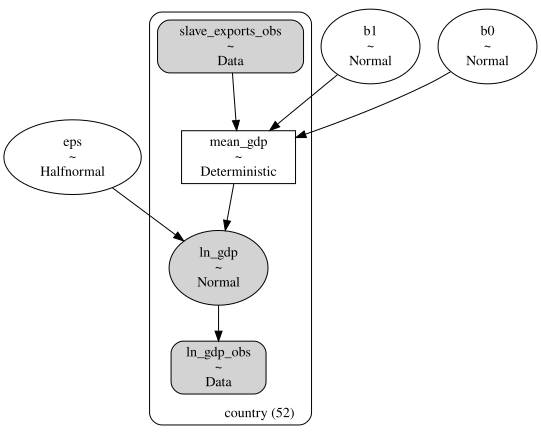

In [54]:
with pm.Model(coords=gdp_coords) as gdp_model:
  # Observed Data
  slave_exports_obs = pm.Data(
    "slave_exports_obs",
    country_df['ln_export_pop'],
    dims='country',
  )
  ln_gdp_obs = pm.Data(
    "ln_gdp_obs",
    country_df['ln_maddison_pcgdp2000'],
    dims='country',
  )
  # X, Y nodes set up in PyMC

  # Parameters
  b0 = pm.Normal('b0', mu=8, sigma=1)
  b1 = pm.Normal('b1', mu=0, sigma=1)
  eps = pm.HalfNormal('eps', mu=0, sigma=1)

  # Linking them together!
  mean_ln_gdp = pm.Deterministic(
    'mean_gdp',
    b0 + b1 * slave_exports_obs,
    dims='country',
  )
  ln_gdp = pm.Normal(
    'ln_gdp',
    mu=mean_ln_gdp, sigma=eps,
    observed=ln_gdp_obs,
    dims='country',
  )

gdp_model.to_graphviz()

It might seem weird that we have to use `with gdp_model` again here, but doing the posterior sampling this way will start to make a ton of sense once we do things like **apply the do() operator** or **ask the model to predict values for *new* unseen observations**:

* Right now we are just telling it "perform the sampling I'm about to write using `gdp_model`, however
* Very soon we will do things like, "perform the sampling I'm about to write using `gdp_model` **modified such that the variable `X` is 'forced' to have value `x`**" (that is, the augmented model produced by applying `do(X = x)`)

In [69]:
with gdp_model:
  idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b0, b1, eps]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [70]:
idata

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:   (chain: 4, draw: 1000, country: 52)
│       Coordinates:
│         * chain     (chain) int64 32B 0 1 2 3
│         * draw      (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * country   (country) <U28 6kB 'Angola' 'Burundi' ... 'Zambia' 'Zimbabwe'
│       Data variables:
│           b0        (chain, draw) float64 32kB 8.421 8.288 7.923 ... 8.234 8.203 7.715
│           b1        (chain, draw) float64 32kB -0.1387 -0.1222 ... -0.1081 -0.07274
│           eps       (chain, draw) float64 32kB 0.6376 0.6977 0.7348 ... 0.7543 0.7646
│           mean_gdp  (chain, draw, country) float64 2MB 6.425 7.804 ... 6.922 7.138
│       Attributes:
│           created_at:                 2026-06-19T21:37:03.057875+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              1.4996953010559082
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│       Data variables: (12/18)
│           reached_max_treedepth  (chain, draw) bool 4kB False False ... False False
│           acceptance_rate        (chain, draw) float64 32kB 0.967 0.9208 ... 0.8395
│           max_energy_error       (chain, draw) float64 32kB 0.1303 0.1968 ... 0.3141
│           energy_error           (chain, draw) float64 32kB -0.09296 ... 0.02252
│           diverging              (chain, draw) bool 4kB False False ... False False
│           process_time_diff      (chain, draw) float64 32kB 0.000677 ... 0.0003208
│           ...                     ...
│           smallest_eigval        (chain, draw) float64 32kB nan nan nan ... nan nan
│           index_in_trajectory    (chain, draw) int64 32kB 8 2 8 1 4 3 ... 1 2 7 -3 6
│           step_size_bar          (chain, draw) float64 32kB 0.4283 0.4283 ... 0.3639
│           energy                 (chain, draw) float64 32kB 59.13 59.47 ... 60.33
│           lp                     (chain, draw) float64 32kB -58.74 -57.83 ... -59.67
│           perf_counter_start     (chain, draw) float64 32kB 3.102e+06 ... 3.102e+06
│       Attributes:
│           created_at:                 2026-06-19T21:37:03.072708+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              1.4996953010559082
│           tuning_steps:               1000
├── Group: /observed_data
│       Dimensions:  (country: 52)
│       Coordinates:
│         * country  (country) <U28 6kB 'Angola' 'Burundi' ... 'Zambia' 'Zimbabwe'
│       Data variables:
│           ln_gdp   (country) float64 416B 6.671 6.354 7.188 ... 5.384 6.501 7.155
│       Attributes:
│           created_at:                 2026-06-19T21:37:03.076930+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.0
│           sample_dims:                []
└── Group: /constant_data
        Dimensions:            (country: 52)
        Coordinates:
          * country            (country) <U28 6kB 'Angola' 'Burundi' ... 'Zimbabwe'
        Data variables:
            slave_exports_obs  (country) float64 416B 14.4 4.452 13.31 ... 10.89 7.925
        Attributes:
          

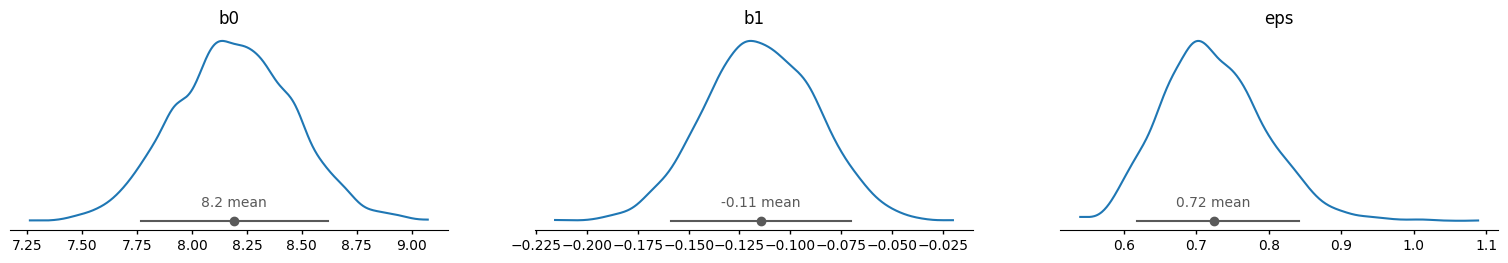

In [71]:
az.plot_dist(
  idata.posterior,
  var_names=['b0','b1','eps'],
);
plt.show()

The above plots are ***the* output** for our model... I can't stress this enough! The entire point of using PyMC is to obtain a **distribution** over model parameters (and predictions), rather than just point estimates. So, when someone asks you to provide **"the"** output/results of your model, the correct thing to show them is the above plot(s)!

However, if someone is annoyed by that, and wants a "statsmodels-style" output, then as a last resort you can *begrudgingly* provide them with point estimates and some indicators of uncertainty by calling `az.summary()`:

In [72]:
az.summary(idata.posterior, var_names=['b0', 'b1', 'eps'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0,8.19,0.268,7.8,8.6,1546,1546,1.00,0.0068,0.0046
b1,-0.115,0.0274,-0.16,-0.07,1524,1488,1.00,0.0007,0.00048
eps,0.724,0.071,0.62,0.84,1890,1980,1.00,0.0016,0.0013


Just please keep in mind how, this is collapsing three **entire distributions** (plotted above) down into just a box containing a few **numbers**... Without the full **distributions**, you will be left with no way to carry out any of the methods we'll learn in the second half of the course, like e.g. **sensitivity analysis**: having the **full information about uncertainty for each parameter** is exactly how we will be able to carry out this kind of "how bad would it be if I'm wrong?" analysis!

In [58]:
b0_mean = float(idata.posterior['b0'].mean())
b1_mean = float(idata.posterior['b1'].mean())
b0_mean, b1_mean

(8.192776586435606, -0.11480798845598969)

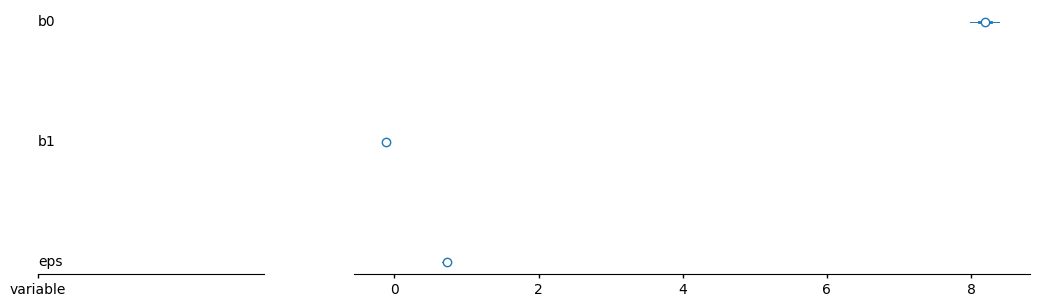

In [60]:
az.plot_forest(idata.posterior.mean('chain'), var_names=['b0', 'b1', 'eps']);
plt.show()

In [33]:
display(idata.posterior['b0'].quantile((.025, .975), dim=("chain", "draw")))
display(idata.posterior['b1'].quantile((.025, .975), dim=("chain", "draw")))

<xarray.DataArray 'b0' (quantile: 2)> Size: 16B
array([7.65930969, 8.71088116])
Coordinates:
  * quantile  (quantile) float64 16B 0.025 0.975

<xarray.DataArray 'b1' (quantile: 2)> Size: 16B
array([-0.167065  , -0.06052311])
Coordinates:
  * quantile  (quantile) float64 16B 0.025 0.975

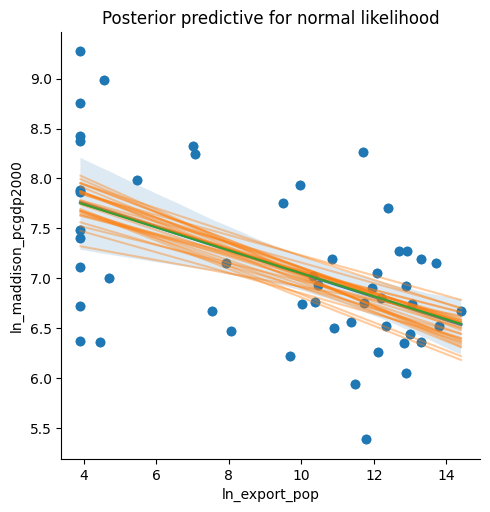

In [34]:
post = az.extract(idata.posterior, num_samples=30)
x_plot = xr.DataArray(
  np.linspace(
    country_df['ln_export_pop'].min(),
    country_df['ln_export_pop'].max(),
    100
  ),
  dims="plot_id"
)
lines = post["b0"] + post["b1"] * x_plot
lines2 = b0_mean + b1_mean * x_plot

sns.lmplot(
  x='ln_export_pop', y='ln_maddison_pcgdp2000',
  data=country_df
);
plt.scatter(country_df['ln_export_pop'], country_df['ln_maddison_pcgdp2000'], label="data")
plt.plot(x_plot, lines.transpose(), alpha=0.4, color="C1")
plt.plot(x_plot, lines2.transpose(), alpha=0.9, color='C2')
plt.title("Posterior predictive for normal likelihood");
plt.show()

## 2 Prior Checks

How did we decide what prior to choose? The answer is... very carefully! Let's look at the impact of our **choice of priors** on the resulting **posterior** distributions

In [35]:
with gdp_model:
  idata_pr = pm.sample_prior_predictive(draws=300)

Sampling: [b0, b1, eps, ln_gdp]


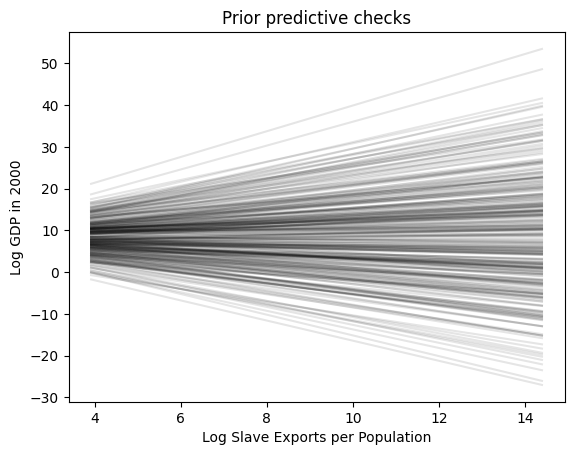

In [36]:
_, ax = plt.subplots()

x = xr.DataArray(
  np.linspace(country_df['ln_export_pop'].min(), country_df['ln_export_pop'].max(), 50),
  dims=["plot_dim"]
)
y = idata_pr.prior["b0"] + idata_pr.prior["b1"] * x

ax.plot(x, y.stack(sample=("chain", "draw")), c="k", alpha=0.1)

ax.set_xlabel("Log Slave Exports per Population")
ax.set_ylabel("Log GDP in 2000")
ax.set_title("Prior predictive checks");


This brings up something a bit... subtle but important about how you can start thinking in a PyMC way rather than an... R or Statsmodels way (though in R, you can use Stan or Ulam instead of PyMC! So if you are an **R** aficionado, this would be "thinking in a Stan rather than `lm` way"): since we are learning a **language** that will allow us to parameterize our models however we'd like, we can think of how we might **customize** this setup to **help us in our modeling task**: in other words, having the model "work for us" rather than trying to adapt our thinking to the model!

Specifically, what I'm referring to here is the fact that **choosing a prior for $\beta_0$ means specifying an "initial guess" (plus an uncertainty about that initial guess) for a *country with exactly one slave exported*** (since $\ln(x) = 0 \iff x = 1$). Think about how this might be a strange "though experiment" for a researcher trying to understand the impact of slave exports on GDP: they may have expertise on essentially the trajectory of the "average" African country's history from the era of the Atlantic Slave Trade to the present... and yet in `statsmodels`, by forcing them to model the **intercept** here, forces them to have to model a case that is by definition the most extreme possible outlier (since number of slaves exported can't be less than 1 given the model setup).

And, it gets worse! Those of you who have studied house prices, for example, may have had to estimate a regression modeling how the square footage of a house impacts its price. Modeling the intercept in that case means trying to imagine what **a house with 0 square feet** might sell for on the housing market...

To avoid this, let's now just make a slight modification to our PyMC model from above to enable us to do what is **much more natural for us as social-scientific modelers: modeling the *average* or "most typical" unit of observation!**

## 3 Posterior Predictive Checks

In [37]:
with gdp_model:
  pm.sample_posterior_predictive(idata, extend_inferencedata=True)

Sampling: [ln_gdp]


Output()

In [38]:
idata.posterior

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:   (chain: 4, draw: 1000, country: 52)
    Coordinates:
      * chain     (chain) int64 32B 0 1 2 3
      * draw      (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
      * country   (country) int64 416B 0 1 2 3 4 5 6 7 8 ... 44 45 46 47 48 49 50 51
    Data variables:
        b0        (chain, draw) float64 32kB 8.4 8.27 8.112 ... 8.309 8.304 7.973
        b1        (chain, draw) float64 32kB -0.1311 -0.1293 ... -0.1318 -0.08817
        eps       (chain, draw) float64 32kB 0.7218 0.7429 0.776 ... 0.8215 0.6326
        mean_gdp  (chain, draw, country) float64 2MB 6.512 7.817 ... 7.012 7.274
    Attributes:
        created_at:                 2026-06-19T19:38:08.574493+00:00
        creation_library:           ArviZ
        creation_library_version:   1.1.0
        creation_library_language:  Python
        inference_library:          pymc
        inference_library_version:  6.0.0
        sample_dims:                ['chain', 'draw']
        sampling_time:              1.5081031322479248
        tuning_steps:               1000

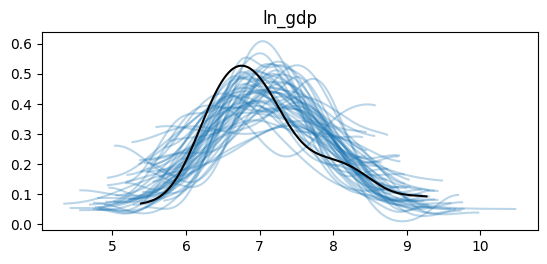

In [39]:
az.plot_ppc_dist(idata, num_samples=50, kind='kde');
plt.show()

In [40]:
post_pred_draws = idata.posterior_predictive['ln_gdp'].mean('chain')

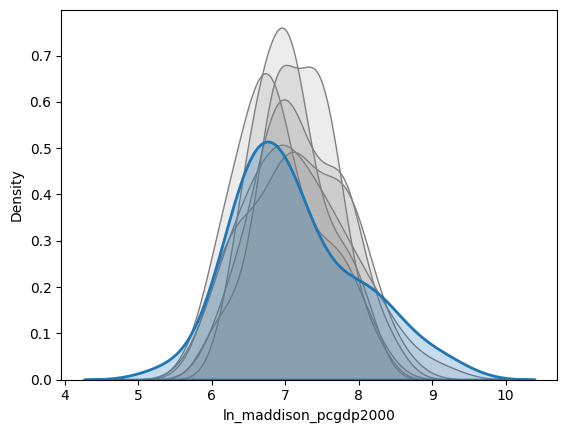

In [41]:
for cur_draw in post_pred_draws[:6]:
  sns.kdeplot(
    cur_draw,
    fill=True, alpha=0.15, color='grey'
  );
sns.kdeplot(country_df['ln_maddison_pcgdp2000'], fill=True, linewidth=2);
plt.show()